In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
nav = pd.read_csv("../data/processed/clean_nav.csv")
fund = pd.read_csv("../data/processed/clean_fund_master.csv")
nav['date'] = pd.to_datetime(nav['date'])

In [3]:
perf = pd.read_csv("../data/processed/clean_performance.csv")
selected_code = perf.nlargest(1, 'aum_crore')['amfi_code'].iloc[0]
selected_name = fund[fund['amfi_code'] == selected_code]['scheme_name'].iloc[0]

In [4]:
fund_nav = nav[nav['amfi_code'] == selected_code].sort_values('date')
fund_nav['daily_return'] = fund_nav['nav'].pct_change()
fund_nav = fund_nav.dropna()

In [5]:
mu = fund_nav['daily_return'].mean()
sigma = fund_nav['daily_return'].std()
last_nav = fund_nav['nav'].iloc[-1]

In [6]:
print(f"Selected Fund: {selected_name}")
print(f"Last NAV: {last_nav:.2f}")
print(f"Daily Mean Return: {mu:.5f}")
print(f"Daily Std Dev: {sigma:.5f}")

Selected Fund: Mirae Asset Emerging Bluechip Fund - Regular - Growth
Last NAV: 205.45
Daily Mean Return: 0.00083
Daily Std Dev: 0.00972


In [7]:
np.random.seed(42)

In [10]:
n_days = 252*2
n_simulations = 1000

In [11]:
simulated_returns = np.random.normal(mu, sigma, (n_days, n_simulations))

In [12]:
simulated_paths = last_nav * np.cumprod(1 + simulated_returns, axis=0)

In [13]:
simulated_paths = np.vstack([np.full(n_simulations, last_nav), simulated_paths])

In [14]:
print(f"Simulated {n_simulations} paths over {n_days} trading days (5 years)")
print(f"Final NAV range: {simulated_paths[-1].min():.2f} to {simulated_paths[-1].max():.2f}")

Simulated 1000 paths over 504 trading days (5 years)
Final NAV range: 152.80 to 573.75


In [15]:
percentiles = [5, 25, 50, 75, 95]
percentile_paths = {p: np.percentile(simulated_paths, p, axis=1) for p in percentiles}

In [16]:
days = np.arange(simulated_paths.shape[0])

In [17]:
print("Final NAV percentiles after 5 years:")
for p in percentiles:
    print(f"  {p}th percentile: {percentile_paths[p][-1]:.2f}")

Final NAV percentiles after 5 years:
  5th percentile: 211.28
  25th percentile: 261.06
  50th percentile: 302.40
  75th percentile: 353.26
  95th percentile: 428.04


In [19]:
plt.figure(figsize=(14, 8))

<Figure size 1400x800 with 0 Axes>

<Figure size 1400x800 with 0 Axes>

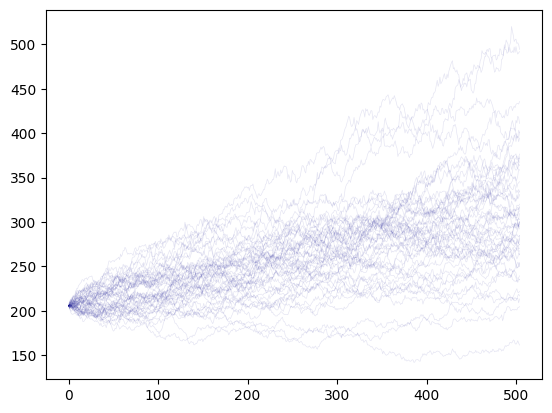

In [22]:
for i in range(0, n_simulations, 20):
    plt.plot(days, simulated_paths[:, i], color='darkblue', alpha=0.1, linewidth=0.5)

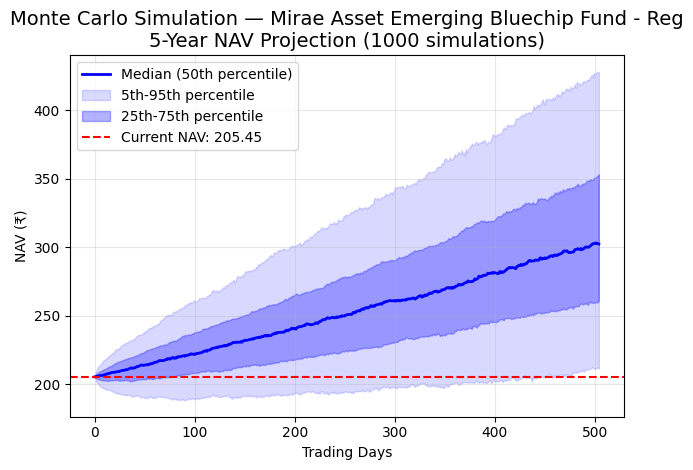

In [21]:
plt.plot(days, percentile_paths[50], color='blue', linewidth=2, label='Median (50th percentile)')
plt.fill_between(days, percentile_paths[5], percentile_paths[95], 
                  color='blue', alpha=0.15, label='5th-95th percentile')
plt.fill_between(days, percentile_paths[25], percentile_paths[75], 
                  color='blue', alpha=0.3, label='25th-75th percentile')

plt.axhline(y=last_nav, color='red', linestyle='--', label=f'Current NAV: {last_nav:.2f}')

plt.title(f'Monte Carlo Simulation — {selected_name[:40]}\n5-Year NAV Projection (1000 simulations)', fontsize=14)
plt.xlabel('Trading Days')
plt.ylabel('NAV (₹)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/charts/monte_carlo_simulation.png")
plt.show()

In [23]:
results_summary = pd.DataFrame({
    'percentile': percentiles,
    'final_nav_5yr': [percentile_paths[p][-1] for p in percentiles],
    'total_return_pct': [(percentile_paths[p][-1] / last_nav - 1) * 100 for p in percentiles]
})

results_summary['scheme_name'] = selected_name
results_summary['current_nav'] = last_nav

results_summary.to_csv("../data/processed/monte_carlo_results.csv", index=False)
print(results_summary)

   percentile  final_nav_5yr  total_return_pct  \
0           5     211.281882          2.838089   
1          25     261.064283         27.068879   
2          50     302.396769         47.186808   
3          75     353.259134         71.943253   
4          95     428.042950        108.343084   

                                         scheme_name  current_nav  
0  Mirae Asset Emerging Bluechip Fund - Regular -...      205.451  
1  Mirae Asset Emerging Bluechip Fund - Regular -...      205.451  
2  Mirae Asset Emerging Bluechip Fund - Regular -...      205.451  
3  Mirae Asset Emerging Bluechip Fund - Regular -...      205.451  
4  Mirae Asset Emerging Bluechip Fund - Regular -...      205.451  


## Monte Carlo Simulation — Key Insights

This simulation projects the NAV of the highest-AUM fund 
(by AUM among the 40 analyzed) over a 5-year horizon using 1,000 
random paths generated from historical daily return distribution 
(mean and standard deviation derived from actual NAV history).

The median projection suggests significant growth potential, while 
the 5th-95th percentile band illustrates the wide range of possible 
outcomes due to market volatility — highlighting the importance of 
long-term investment horizons for equity mutual funds.

**Caveat:** This simulation assumes returns are normally distributed 
and independent across days, which is a simplification of real market 
behavior (which exhibits volatility clustering and fat tails).
